# RQ3 — Test Quality Evaluation

*Real-only notebook: loads the latest persisted experiment report JSON and analyzes it. No simulations.*


## Load latest RQ3 report

In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)

REPORT_DIR = Path('../results/rq3')
report_files = sorted(REPORT_DIR.glob('rq3_report_*.json'), key=lambda p: p.stat().st_mtime, reverse=True)
if not report_files:
    raise FileNotFoundError(
        f'No RQ3 report found in {REPORT_DIR.resolve()}. Run experiments/rq3_quality_validation.py to generate rq3_report_*.json'
    )
REPORT_PATH = report_files[0]
print('Using report:', REPORT_PATH)

report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
report.keys()


Using report: ../results/rq3/rq3_report_httpbin_testing_api_c100_llama32_20251213_041306.json


dict_keys(['experiment_id', 'config', 'started_at', 'completed_at', 'total_endpoints', 'endpoint_results', 'aggregate_metrics', 'llm_rankings', 'quality_gates'])

## Endpoint-level quality table

In [2]:
rows = []
for er in report.get('endpoint_results', []):
    qs = (er.get('quality_scores') or {})
    sm = (er.get('specific_metrics') or {})
    qf = (er.get('quality_flags') or {})
    rows.append({
        'endpoint_id': er.get('endpoint_id'),
        'endpoint_name': er.get('endpoint_name'),
        'llm_model': er.get('llm_model'),
        'correctness': qs.get('correctness'),
        'readability': qs.get('readability'),
        'maintainability': qs.get('maintainability'),
        'overall': qs.get('overall'),
        'assertion_count': sm.get('assertion_count'),
        'valid_assertions': sm.get('valid_assertions'),
        'lines_of_code': sm.get('lines_of_code'),
        'cyclomatic_complexity': sm.get('cyclomatic_complexity'),
        'code_duplication_ratio': sm.get('code_duplication_ratio'),
        'code_smells_count': sm.get('code_smells_count'),
        'meets_quality_threshold': qf.get('meets_quality_threshold'),
        'has_compilation_errors': qf.get('has_compilation_errors'),
        'has_code_smells': qf.get('has_code_smells'),
        'execution_time_ms': er.get('execution_time_ms'),
        'error_message': er.get('error_message'),
    })

endpoint_quality_df = pd.DataFrame(rows)
endpoint_quality_df.head(10)


,endpoint_id,endpoint_name,llm_model,correctness,readability,maintainability,overall,assertion_count,valid_assertions,lines_of_code,cyclomatic_complexity,code_duplication_ratio,code_smells_count,meets_quality_threshold,has_compilation_errors,has_code_smells,execution_time_ms,error_message
0,f080b308-6bbf-43a7-854a-9c670ec1132a,GET request,fallback,0.60,0.9,1.0,0.81,1,1,48,0.0,0.0,0,False,False,False,3.935,'ReadabilityMetrics' object has no attribute '...
1,6c560818-a3f8-40f3-8854-cb999e6dae9e,POST request,fallback,0.60,0.9,1.0,0.81,1,1,48,0.0,0.0,0,False,False,False,1.322,'ReadabilityMetrics' object has no attribute '...
2,5da2add9-204b-460f-b908-9ae501e67f8f,Status 200,fallback,0.60,0.9,1.0,0.81,1,1,48,0.0,0.0,0,False,False,False,1.058,'ReadabilityMetrics' object has no attribute '...
3,f7ff8cb5-a0a9-483a-bb3e-8b1d0bc7d143,Status 404,consensus_1_models,0.35,1.0,1.0,0.74,4,2,58,0.0,0.0,0,False,False,False,1.552,'ReadabilityMetrics' object has no attribute '...
4,45085b49-122c-4bb1-900b-881b3d17aba0,Status 500,fallback,0.60,0.9,1.0,0.81,1,1,48,0.0,0.0,0,False,False,False,1.225,'ReadabilityMetrics' object has no attribute '...
5,6d3f5610-56f0-4eb0-b2d8-12008263afdc,Get headers,fallback,0.60,0.9,1.0,0.81,1,1,48,0.0,0.0,0,False,False,False,1.016,'ReadabilityMetrics' object has no attribute '...
6,5ce0c2f9-2178-4290-8fe4-9d0e4c7aa3cb,Delayed response,consensus_1_models,0.50,1.0,1.0,0.80,4,2,60,0.0,0.0,0,False,False,False,1.478,'ReadabilityMetrics' object has no attribute '...
7,c4eee30c-ac2d-4dcb-88bd-d371164ba647,Basic authentication,consensus_1_models,0.50,1.0,1.0,0.80,5,3,62,0.0,0.0,0,False,False,False,1.613,'ReadabilityMetrics' object has no attribute '...


## Aggregate metrics (from report)

In [3]:
aggregate_metrics = report.get('aggregate_metrics', {}) or {}
aggregate_df = (
    pd.DataFrame.from_dict(aggregate_metrics, orient='index')
      .reset_index(names='llm_model')
      .sort_values('overall_mean', ascending=False)
)

display(aggregate_df)


,llm_model,correctness_mean,correctness_std,readability_mean,readability_std,maintainability_mean,maintainability_std,overall_mean,overall_std,avg_complexity,avg_duplication,avg_code_smells,pass_rate
0,fallback,0.60,0.000000,0.9,0.0,1.0,0.0,0.81,0.000000,0.0,0.0,0,0.0
1,consensus_1_models,0.45,0.086603,1.0,0.0,1.0,0.0,0.78,0.034641,0.0,0.0,0,0.0


## Visualizations

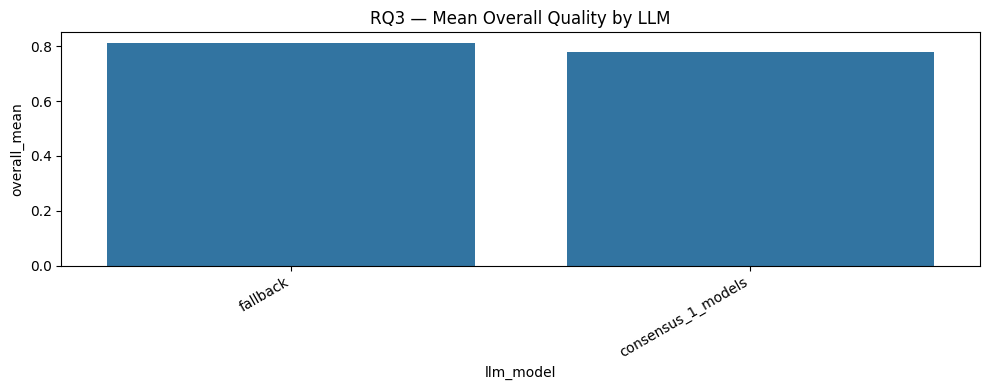

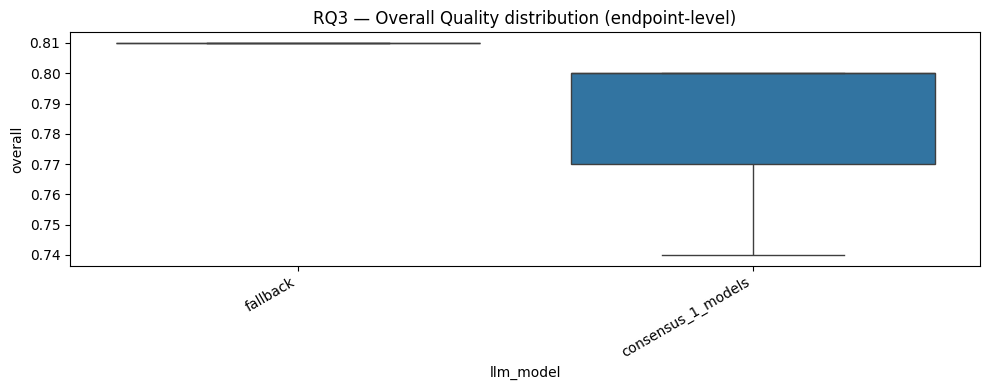

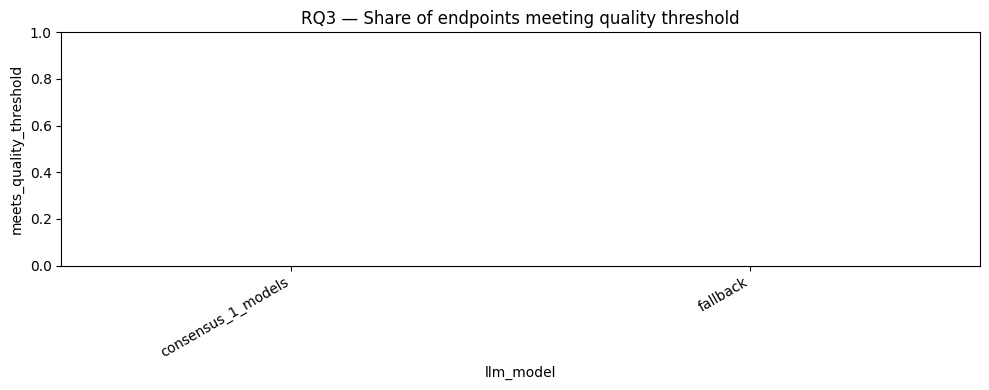

In [4]:
if not aggregate_df.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=aggregate_df, x='llm_model', y='overall_mean')
    plt.title('RQ3 — Mean Overall Quality by LLM')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

if not endpoint_quality_df.empty:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=endpoint_quality_df, x='llm_model', y='overall')
    plt.title('RQ3 — Overall Quality distribution (endpoint-level)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    gate = endpoint_quality_df.groupby('llm_model')['meets_quality_threshold'].mean().reset_index()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=gate, x='llm_model', y='meets_quality_threshold')
    plt.title('RQ3 — Share of endpoints meeting quality threshold')
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


## Export

In [5]:
OUT_DIR = Path('./outputs/rq3')
OUT_DIR.mkdir(parents=True, exist_ok=True)

endpoint_quality_df.to_csv(OUT_DIR / 'rq3_endpoint_quality.csv', index=False)
aggregate_df.to_csv(OUT_DIR / 'rq3_aggregate_metrics.csv', index=False)

summary = {
    'report_path': str(REPORT_PATH),
    'experiment_id': report.get('experiment_id'),
    'total_endpoints': report.get('total_endpoints'),
    'llm_rankings': report.get('llm_rankings'),
    'quality_gates': report.get('quality_gates'),
}
(OUT_DIR / 'rq3_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Wrote:', OUT_DIR)


Wrote: outputs/rq3
